In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("solar_eolica_hidro_horario_2024.csv", index_col="datetime", parse_dates=["datetime"])
df

,solar_mw_real,eolica_mw_real,hidro_mw_real
datetime,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698
2024-01-01 02:00:00,0.0,123.2682,427.5446
2024-01-01 03:00:00,0.0,170.8097,337.3828
2024-01-01 04:00:00,0.0,95.7732,411.8209
2024-01-01 05:00:00,0.0,101.6279,383.3069
...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103
2024-12-31 21:00:00,0.0,77.8649,760.3992
2024-12-31 22:00:00,0.0,35.3924,729.7733


In [3]:
df2 = pd.read_csv("DEM2024.csv", skiprows=2, thousands=",")
df2 = df2.rename(columns={"Unnamed: 0": "Date"})
df2["Date"] = pd.to_datetime(df2["Date"], errors="coerce")
df2 = df2.dropna(subset=["Date"])

df2 = df2.melt(id_vars="Date", var_name="Hour", value_name="Demand MW")
df2["datetime"] = df2["Date"] + pd.to_timedelta(df2["Hour"].str[1:].astype(int), unit="h")
demand = df2.set_index("datetime")[["Demand MW"]].sort_index()

In [4]:
merged = df.join(demand)
merged

,solar_mw_real,eolica_mw_real,hidro_mw_real,Demand MW
datetime,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3
...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7


In [5]:
merged.rename ( {"solar_mw_real" : "Solar MW", 	"eolica_mw_real": "Wind MW", "hidro_mw_real": "Hydro MW"}, axis = 1, inplace = True)

In [6]:
merged

,Solar MW,Wind MW,Hydro MW,Demand MW
datetime,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3
...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7


In [7]:
df = merged

In [8]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW
datetime,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3
...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7


Text(0.5, 1.0, 'Hourly System Demand and Renewables Generation')

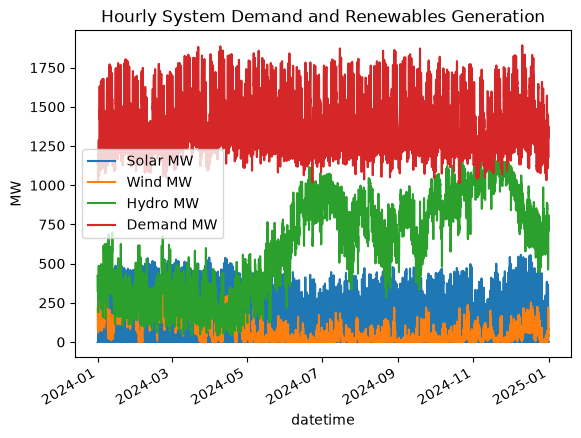

In [9]:
df.plot()

plt.ylabel("MW")
plt.title ("Hourly System Demand and Renewables Generation")


In [10]:
for k in df.index:

    if df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"] > df.loc[k, "Demand MW"]:
        df.loc[k, "Net load MW"] = 0
    else:
        df.loc[k, "Net load MW"] = df.loc[k, "Demand MW"] - (df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"])

In [11]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW,Net load MW
datetime,,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6,593.1465
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0,596.1872
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0,624.8075
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8,599.2059
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3,605.3652
...,...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4,474.9147
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5,507.2359
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7,520.5343


Text(0.5, 1.0, 'Net Load')

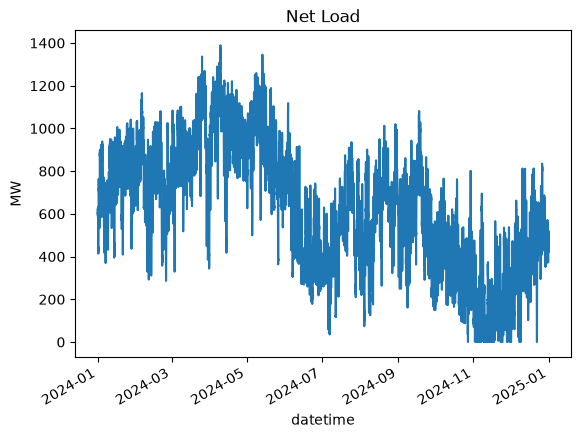

In [12]:
df["Net load MW"].plot()

plt.ylabel("MW")
plt.title ("Net Load")

Text(0.5, 1.0, 'Net Load')

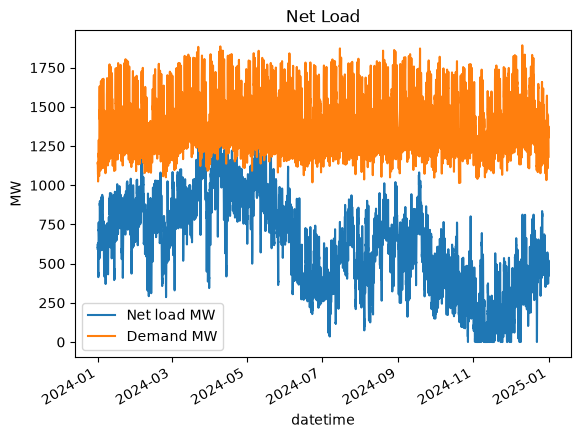

In [13]:
df[["Net load MW", "Demand MW"]].plot()

plt.ylabel("MW")
plt.title ("Net Load")

In [14]:
check = df[ "Net load MW"] > df[ "Demand MW"]
check

datetime
2024-01-01 01:00:00    False
2024-01-01 02:00:00    False
2024-01-01 03:00:00    False
2024-01-01 04:00:00    False
2024-01-01 05:00:00    False
                       ...  
2024-12-31 20:00:00    False
2024-12-31 21:00:00    False
2024-12-31 22:00:00    False
2024-12-31 23:00:00    False
2025-01-01 00:00:00    False
Length: 8736, dtype: bool

In [15]:
sum(check)


0

In [16]:
for k in df.index:

    if df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"] > df.loc[k, "Demand MW"]:
        df.loc[k, "Renewables Share %"] = 100
    else:
        df.loc[k, "Renewables Share %"] =  (df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"])/ df.loc[k, "Demand MW"]*100

In [17]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW,Net load MW,Renewables Share %
datetime,,,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6,593.1465,47.951343
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0,596.1872,48.022040
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0,624.8075,44.853707
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8,599.2059,45.861411
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3,605.3652,44.477190
...,...,...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4,474.9147,65.420511
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5,507.2359,62.301308
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7,520.5343,59.513549


Text(0.5, 1.0, ' Annual Renewable Contribuiton to Meet hourly Demand %')

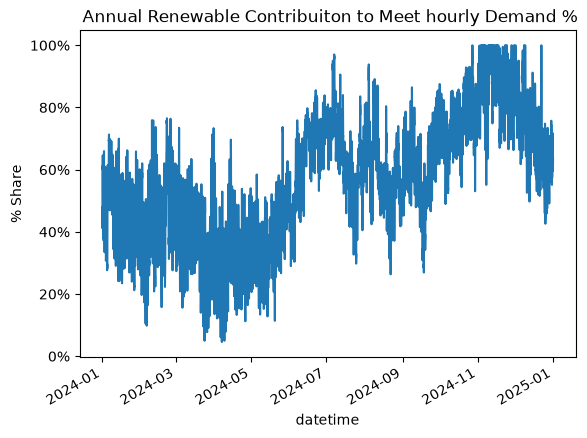

In [18]:
fig, ax = plt.subplots()
ax = df["Renewables Share %"].plot()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.ylabel("% Share")
plt.title(" Annual Renewable Contribuiton to Meet hourly Demand %")